# Parquet Pipeline

In [1]:
%load_ext autoreload
%autoreload 2

import sys, logging, importlib

# Ensure your scripts dir is importable
sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/scripts/postprocessing")

# 1) Set global logging and quiet noisy libs
logging.basicConfig(
    level=logging.DEBUG,
    format="%(asctime)s - %(levelname)s - %(name)s - %(message)s",
    force=True,
)
for noisy in ["uproot", "fsspec", "s3fs", "urllib3", "numexpr", "matplotlib"]:
    logging.getLogger(noisy).setLevel(logging.WARNING)

# 2) Turn up only your modules to DEBUG (others inherit WARNING from above)
for name in [
    "convert_all",
    "convert_particles",
    "convert_digihits",
    "convert_tracks",
    "utils",
    "utils.track_utils",
    "utils.driver",
    "utils.path_utils",
]:
    logging.getLogger(name).setLevel(logging.DEBUG)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot
import sys
import seaborn as sns
from tqdm import tqdm
import networkx as nx
import matplotlib.cm as cm
import h5py
import pyarrow as pa
import pyarrow.parquet as pq
import logging
import awkward as ak
import uproot

import atlasify as atl
from particle import Particle
atl.ATLAS = "ColliderML"

import pyhepmc as hep
from pyhepmc.io import WriterAscii

sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/OtherLibraries/pyedm4hep")
from pyedm4hep import EDM4hepEvent, EDM4hepEventBatch

from pathlib import Path
import logging

# Reuse postprocessing helpers
sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/scripts/postprocessing")
from convert_particles import build_particles_df_with_parents_and_vertex, write_particles_with_selection
from convert_digihits import process_event_for_digihits, write_digihits_with_selection
from convert_calorimeter import write_calohits_with_selection
from utils.path_utils import get_run_paths, make_dir
from utils.track_utils import load_root_file, load_track_summary, create_particle_barcode_map

from convert_all import convert_all


2025-10-31 05:58:26,040 - DEBUG - h5py._conv - Creating converter from 7 to 5
2025-10-31 05:58:26,041 - DEBUG - h5py._conv - Creating converter from 5 to 7
2025-10-31 05:58:26,041 - DEBUG - h5py._conv - Creating converter from 7 to 5
2025-10-31 05:58:26,042 - DEBUG - h5py._conv - Creating converter from 5 to 7
2025-10-31 05:58:26,041 - DEBUG - h5py._conv - Creating converter from 5 to 7
2025-10-31 05:58:26,041 - DEBUG - h5py._conv - Creating converter from 7 to 5
2025-10-31 05:58:26,042 - DEBUG - h5py._conv - Creating converter from 5 to 7


### Roadmap

- Load parquet files (tracks, tracker_hits, calo_hits, particles)
- Calculate the run that corresponds to that event
- Load edm4hep file (edm4hep.root), looking just at that event
- Using position and vertex merges, ensure that ALL hits and particles are present in the edm4hep file
- Visualise the event (hits, tracks)
- Deduce the hepmc file and event number from the edm4hep event
- Load the hepmc file and event number in hard scatter AND merged versions
- Ensure that ALL generator particles are present in the hepmc files and vice versa

## Testing parquet outputs

In [3]:
import pandas as pd
import pyarrow.parquet as pq
import numpy as np
import polars as pl

def load_all_particles_parquet(parquet_path, event_id=None):
    """
    Load particles data from Parquet file using Polars for fast exploding.
    
    Args:
        parquet_path: Path to Parquet file
        event_id: Optional specific event ID to load. If None, loads all events.
    
    Returns:
        DataFrame with particles data (flat format with one row per particle)
    """
    # Read parquet file with Polars
    df = pl.read_parquet(parquet_path)
    
    if df.is_empty():
        return pd.DataFrame()
    
    if event_id is not None:
        # Filter to specific event
        df = df.filter(pl.col('event_id') == event_id)
        if df.is_empty():
            return pd.DataFrame()
    
    # Check if data needs exploding by examining first non-event_id column
    non_event_cols = [c for c in df.columns if c != 'event_id']
    if not non_event_cols:
        return df.to_pandas()
    
    # Check if the column dtype is a List type
    if df[non_event_cols[0]].dtype == pl.List:
        # Use Polars explode for fast unnesting
        df_exploded = df.explode(non_event_cols)
        return df_exploded.to_pandas()
    else:
        # Data is already flat
        return df.to_pandas()


def load_all_digihits_parquet(parquet_path, event_id=None):
    """
    Load digihits data from Parquet file using Polars.
    
    Args:
        parquet_path: Path to Parquet file
        event_id: Optional specific event ID to load. If None, loads all events.
    
    Returns:
        DataFrame with digihits data (flat format with one row per hit)
    """
    # Read parquet file with Polars
    df = pl.read_parquet(parquet_path)
    
    if df.is_empty():
        return pd.DataFrame()
    
    if event_id is not None:
        df = df.filter(pl.col('event_id') == event_id)
        if df.is_empty():
            return pd.DataFrame()
    
    # Check if data needs exploding
    non_event_cols = [c for c in df.columns if c != 'event_id']
    if not non_event_cols:
        return df.to_pandas()
    
    # Check if the column dtype is a List type
    if df[non_event_cols[0]].dtype == pl.List:
        # Use Polars explode for fast unnesting
        df_exploded = df.explode(non_event_cols)
        return df_exploded.to_pandas()
    else:
        # Data is already flat
        return df.to_pandas()


def load_all_tracks_parquet(parquet_path, event_id=None):
    """
    Load tracks data from Parquet file using Polars.
    
    Args:
        parquet_path: Path to Parquet file
        event_id: Optional specific event ID to load. If None, loads all events.
    
    Returns:
        Tuple of (tracks_df, hits_df) where hits_df contains track hit associations
    """
    # Read parquet file with Polars
    df = pl.read_parquet(parquet_path)
    
    if df.is_empty():
        return pd.DataFrame(), None
    
    if event_id is not None:
        df = df.filter(pl.col('event_id') == event_id)
        if df.is_empty():
            return pd.DataFrame(), None
    
    # Check if data needs exploding
    non_event_cols = [c for c in df.columns if c != 'event_id']
    if not non_event_cols:
        df_pandas = df.to_pandas()
        if 'hit_ids' in df_pandas.columns:
            hits_df = df_pandas[['event_id', 'track_id', 'hit_ids']].copy()
            tracks_df = df_pandas.drop(columns=['hit_ids'])
            return tracks_df, hits_df
        return df_pandas, None
    
    # Check if the column dtype is a List type
    if df[non_event_cols[0]].dtype != pl.List:
        # Data is already flat
        df_pandas = df.to_pandas()
        if 'hit_ids' in df_pandas.columns:
            hits_df = df_pandas[['event_id', 'track_id', 'hit_ids']].copy()
            tracks_df = df_pandas.drop(columns=['hit_ids'])
            return tracks_df, hits_df
        return df_pandas, None
    
    # Handle hit_ids separately (nested lists that should be preserved)
    has_hit_ids = 'hit_ids' in df.columns
    
    # Separate hit_ids from other columns
    track_cols = [c for c in non_event_cols if c != 'hit_ids']
    
    if track_cols:
        # Explode track data
        df_tracks = df.select(['event_id'] + track_cols).explode(track_cols)
        tracks_df = df_tracks.to_pandas()
    else:
        tracks_df = pd.DataFrame()
    
    # Handle hit_ids separately if present
    hits_df = None
    if has_hit_ids and 'track_id' in tracks_df.columns:
        # Explode hit_ids but keep inner lists
        df_hits = df.select(['event_id', 'hit_ids']).explode('hit_ids')
        hits_df = df_hits.to_pandas()
        # Add track_id from tracks_df
        hits_df['track_id'] = tracks_df['track_id'].values
    
    return tracks_df, hits_df


def load_all_calohits_parquet(parquet_path, event_id=None):
    """
    Load calorimeter hits data from Parquet file using Polars.
    
    Calorimeter data has nested contribution lists (particle IDs, energies, times)
    that are kept as lists in the output, representing multiple particle contributions
    to each cell.
    
    Args:
        parquet_path: Path to Parquet file
        event_id: Optional specific event ID to load. If None, loads all events.
    
    Returns:
        DataFrame with calorimeter hits (flat format with one row per cell, 
        with nested contribution lists preserved)
    """
    # Read parquet file with Polars
    df = pl.read_parquet(parquet_path)
    
    if df.is_empty():
        return pd.DataFrame()
    
    if event_id is not None:
        df = df.filter(pl.col('event_id') == event_id)
        if df.is_empty():
            return pd.DataFrame()
    
    # Check if data needs exploding
    non_event_cols = [c for c in df.columns if c != 'event_id']
    if not non_event_cols:
        return df.to_pandas()
    
    # Identify contribution columns (nested lists that should be preserved)
    contrib_cols = [c for c in df.columns if c.startswith('contrib_')]
    
    # Get first non-contribution column to check if data needs exploding
    non_contrib_cols = [c for c in non_event_cols if c not in contrib_cols]
    if not non_contrib_cols:
        return df.to_pandas()
    
    # Check if the column dtype is a List type
    if df[non_contrib_cols[0]].dtype != pl.List:
        # Data is already flat
        return df.to_pandas()
    
    # Explode scalar columns but keep contribution columns as nested lists
    df_exploded = df.explode(non_contrib_cols)
    
    # Convert to pandas
    return df_exploded.to_pandas()


In [4]:
global_event_id = 0
chunk_size = 100
chunk_number = global_event_id // chunk_size
event_range = f"events{chunk_number*chunk_size}-{chunk_number*chunk_size+chunk_size-1}"

In [5]:
event_range

'events0-99'

In [6]:
# Update file paths to point to parquet files
particles_file = f"/global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup/ttbar/v1/parquet/truth/particles/full_pileup.ttbar.v1.truth.particles.{event_range}.parquet"
digihits_file = f"/global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup/ttbar/v1/parquet/reco/tracker_hits/full_pileup.ttbar.v1.reco.tracker_hits.{event_range}.parquet"
tracks_file = f"/global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup/ttbar/v1/parquet/reco/tracks/full_pileup.ttbar.v1.reco.tracks.{event_range}.parquet"
calohits_file = f"/global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup/ttbar/v1/parquet/reco/calo_hits/full_pileup.ttbar.v1.reco.calo_hits.{event_range}.parquet"

In [11]:
# Test loading a single event from parquet with improved functions
parquet_particles_df = load_all_particles_parquet(particles_file, event_id=global_event_id)
parquet_trackerhits_df = load_all_digihits_parquet(digihits_file, event_id=global_event_id)
parquet_tracks_df, parquet_track_hits_df = load_all_tracks_parquet(tracks_file, event_id=global_event_id)
parquet_calohits_df = load_all_calohits_parquet(calohits_file, event_id=global_event_id)

print(f"Loaded event {global_event_id}:")
print(f"  Particles: {len(parquet_particles_df)} rows")
print(f"  Digihits: {len(parquet_trackerhits_df)} rows")
print(f"  Tracks: {len(parquet_tracks_df)} rows")
print(f"  Calohits: {len(parquet_calohits_df)} rows")
if parquet_track_hits_df is not None:
    print(f"  Track hit associations: {len(parquet_track_hits_df)} rows")

print("\nParticles sample:")
print(parquet_particles_df.head() if not parquet_particles_df.empty else "Empty")

print("\nDigihits sample:")
print(parquet_trackerhits_df.head() if not parquet_trackerhits_df.empty else "Empty")

print("\nTracks sample:")
print(parquet_tracks_df.head() if not parquet_tracks_df.empty else "Empty")

Loaded event 0:
  Particles: 149947 rows
  Digihits: 214903 rows
  Tracks: 640 rows
  Calohits: 396223 rows
  Track hit associations: 640 rows

Particles sample:
   event_id  particle_id  pdg_id     mass       energy  charge        vx  \
0         0           15     211  0.13957  4139.211789     1.0 -0.011325   
1         0           80    -521  5.27925   175.691917    -1.0 -0.011325   
2         0           81    3122  1.11568    13.754840     0.0 -0.011325   
3         0           82   -3112  1.19745    10.019325     1.0 -0.011325   
4         0           83    -211  0.13957     1.124754    -1.0 -0.011325   

         vy          vz      time            px            py           pz  \
0 -0.007458  116.524422 -0.221602 -1.860858e-09  4.662397e-08  4139.211914   
1 -0.007458  116.524422 -0.221602  1.256247e+01 -3.777593e+01   171.040756   
2 -0.007458  116.524422 -0.221602  8.001726e-01 -2.574466e+00    13.441828   
3 -0.007458  116.524422 -0.221602  1.131750e+00 -1.690892e+00     9.7

In [12]:
parquet_particles_df

,event_id,particle_id,pdg_id,mass,energy,charge,vx,vy,vz,time,px,py,pz,vertex_primary,parent_id
0,0,15,211,0.139570,4139.211789,1.0,-0.011325,-0.007458,116.524422,-0.221602,-1.860858e-09,4.662397e-08,4139.211914,1,9.0
1,0,80,-521,5.279250,175.691917,-1.0,-0.011325,-0.007458,116.524422,-0.221602,1.256247e+01,-3.777593e+01,171.040756,1,10.0
2,0,81,3122,1.115680,13.754840,0.0,-0.011325,-0.007458,116.524422,-0.221602,8.001726e-01,-2.574466e+00,13.441828,1,10.0
3,0,82,-3112,1.197450,10.019325,1.0,-0.011325,-0.007458,116.524422,-0.221602,1.131750e+00,-1.690892e+00,9.737197,1,10.0
4,0,83,-211,0.139570,1.124754,-1.0,-0.011325,-0.007458,116.524422,-0.221602,9.911107e-02,-5.240666e-01,0.980368,1,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149942,0,184990,11,0.000511,0.000778,-1.0,-664.198364,-473.025024,-111.586510,201.315033,-1.143570e-04,-7.443827e-05,-0.000571,1,184991.0
149943,0,184991,-211,0.139570,0.502607,-1.0,141.049088,-641.556763,3264.950195,10.572216,-4.672403e-01,-9.341014e-04,0.121737,1,213.0
149944,0,184992,11,0.000511,0.187757,-1.0,-56.644218,-625.888367,3296.896973,11.322639,-1.465972e-01,-7.119232e-02,-0.093238,1,184993.0
149945,0,184993,11,0.000511,0.287490,-1.0,175.211533,-629.577942,3216.613281,10.347099,6.062873e-02,-2.246457e-01,0.168845,1,NaN


In [13]:
parquet_trackerhits_df

,event_id,x,y,z,true_x,true_y,true_z,time,particle_id,cell_id,detector,volume_id,layer_id,surface_id
0,0,47.325001,7.075000,-1515.599976,47.337048,7.095499,-1515.599976,-5.113974,18989,16982300688487,1,16,4,1
1,0,52.175003,-7.475000,-1515.599976,52.155815,-7.469731,-1515.599976,-5.106862,156787,639950127207,1,16,4,1
2,0,60.924999,-9.225000,-1515.599976,60.942432,-9.218755,-1515.599976,-5.101593,156799,790273982567,1,16,4,1
3,0,77.432602,6.575000,-1515.599976,77.440285,6.574460,-1515.599976,-5.063385,157055,17029545328743,1,16,4,1
4,0,68.925003,6.325000,-1515.599976,68.924652,6.306347,-1515.599976,-5.001588,156758,17051020165223,1,16,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
214898,0,349.984802,925.928772,3009.500000,350.761627,927.832886,3009.562012,19.148195,94004,16707423867230,5,30,12,192
214899,0,342.999695,928.659790,3009.500000,344.041565,931.297058,3009.403076,20.213150,184096,16488380535134,5,30,12,192
214900,0,430.662811,894.385986,3009.500000,434.833649,905.190613,3009.500000,26.139853,83512,1589138985310,5,30,12,192
214901,0,340.322083,929.706665,3009.500000,347.662811,948.423645,3009.390137,68.022552,128451,16406776156510,5,30,12,192


In [14]:
parquet_tracks_df

,event_id,d0,z0,phi,theta,qop,majority_particle_id,track_id
0,0,-0.019927,22.764204,3.120487,2.180318,0.752686,10241,1397
1,0,-0.045125,-70.127899,3.012332,2.999990,-0.108145,52810,1395
2,0,-0.017185,45.043503,3.100641,1.460943,0.596817,57154,1392
3,0,-0.023339,46.637302,3.063131,0.946491,-0.674928,72961,1388
4,0,0.075199,76.919601,3.077874,0.301729,-0.195834,34264,1385
...,...,...,...,...,...,...,...,...
635,0,-0.120479,67.138374,2.016934,2.938154,-0.199385,50425,1141
636,0,-0.099249,59.913776,3.116702,0.426273,-0.381865,68999,37
637,0,-0.086987,79.702995,1.993310,2.762965,-0.163627,20176,1146
638,0,0.012718,-23.158419,2.126687,2.931180,0.092380,70408,1171


In [15]:
parquet_track_hits_df

,event_id,track_id,hit_ids
0,0,1397,"[37804, 49584, 49779, 59738, 109866, 125480, 1..."
1,0,1395,"[33282, 18563, 15779, 12861, 14761, 14728, 117..."
2,0,1392,"[33698, 37850, 49604, 49808, 59760, 109553, 12..."
3,0,1388,"[33668, 37878, 49831, 59902, 110312, 125863, 1..."
4,0,1385,"[33807, 37644, 49714, 67021, 110427, 151155, 1..."
...,...,...,...
635,0,1141,"[30963, 35676, 36002, 47851, 20154, 17404, 102..."
636,0,37,"[33760, 37917, 49681, 60063, 110821, 125927, 1..."
637,0,1146,"[31015, 35710, 47967, 58211, 107526, 123201, 1..."
638,0,1171,"[30824, 31705, 35966, 20132, 17383, 102802, 99..."


In [16]:
parquet_calohits_df

,event_id,detector,total_energy,x,y,z,contrib_particle_ids,contrib_energies,contrib_times
0,0,ECalBarrelCollection,0.000064,96.900002,-1282.699951,-2606.100098,[75527],[6.367175956256688e-05],[17.505346298217773]
1,0,ECalBarrelCollection,0.000259,96.900002,-1282.699951,-2601.000000,[75527],[0.0002594864636193961],[17.506690979003906]
2,0,ECalBarrelCollection,0.000209,617.349609,-1263.855835,-1611.599976,[75603],[0.00020931375911459327],[16.551158905029297]
3,0,ECalBarrelCollection,0.000416,606.122620,-1170.116699,-1621.800049,[75603],[0.00041606323793530464],[14.446691513061523]
4,0,ECalBarrelCollection,0.000331,586.667969,-1216.437744,-1626.900024,[75603],[0.00033088267082348466],[13.574856758117676]
...,...,...,...,...,...,...,...,...,...
396218,0,HCalEndcapCollection,0.001241,210.000000,-1262.489136,4055.500000,[184937],[0.001240716315805912],[14.527225494384766]
396219,0,HCalEndcapCollection,0.001886,210.000000,-1322.489136,4106.500000,[184937],[0.001885654404759407],[14.881858825683594]
396220,0,HCalEndcapCollection,0.000693,595.729736,-680.582581,3902.500000,[184890],[0.0006926940404810011],[19.231666564941406]
396221,0,HCalEndcapCollection,0.001954,723.008972,-680.582581,4004.500000,[184890],[0.0019544081296771765],[16.8963680267334]


## Validation Checks

In [35]:
# Add number of hits to particles_df
num_tracker_hits = parquet_trackerhits_df.groupby("particle_id").size()
parquet_particles_df["num_tracker_hits"] = parquet_particles_df.particle_id.map(num_tracker_hits)
parquet_tracks_df["num_particle_hits"] = parquet_tracks_df.merge(parquet_particles_df[["particle_id", "num_tracker_hits"]], left_on="majority_particle_id", right_on="particle_id", how="left").num_tracker_hits
parquet_tracks_df["num_track_hits"] = parquet_track_hits_df.hit_ids.apply(len)
parquet_tracks_df["hit_ids"] = parquet_track_hits_df.hit_ids

def get_num_shared_hits(track_row):
    track_hit_ids = track_row.hit_ids
    particle_hit_ids = parquet_trackerhits_df[parquet_trackerhits_df.particle_id == track_row.majority_particle_id].index.tolist()
    return len(set(track_hit_ids) & set(particle_hit_ids))

parquet_tracks_df["num_shared_hits"] = parquet_tracks_df.apply(get_num_shared_hits, axis=1)

In [18]:
parquet_tracks_df["efficiency"] = parquet_tracks_df["num_shared_hits"] / parquet_tracks_df["num_particle_hits"]
parquet_tracks_df["purity"] = parquet_tracks_df["num_shared_hits"] / parquet_tracks_df["num_track_hits"]

In [19]:
print(f"Efficiency: {parquet_tracks_df.efficiency.mean()}, Purity: {parquet_tracks_df.purity.mean()}")

Efficiency: 0.9575330160492458, Purity: 0.9780078855733727


Text(0.5, 1.0, 'Track 0: Track hits vs True particle hits, track ID: 1397')

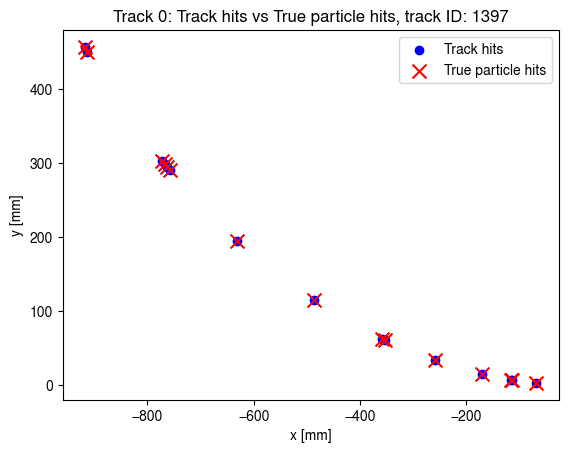

In [20]:
track_index = 0
track_hit_ids = parquet_track_hits_df.iloc[track_index].hit_ids

plt.scatter(parquet_trackerhits_df.x.iloc[track_hit_ids], parquet_trackerhits_df.y.iloc[track_hit_ids], marker='o', color="b", label="Track hits")

# Get the majority particle id for the track
track_majority_particle_id = parquet_tracks_df.iloc[track_index]['majority_particle_id']

# Get the hit ids for the majority particle id
majority_particle_hit_ids = parquet_trackerhits_df[parquet_trackerhits_df.particle_id == track_majority_particle_id].index.tolist()
plt.scatter(parquet_trackerhits_df.x.iloc[majority_particle_hit_ids], parquet_trackerhits_df.y.iloc[majority_particle_hit_ids], marker='x', color="red", s=100, label="True particle hits")

# Add legend
plt.legend()
plt.xlabel("x [mm]")
plt.ylabel("y [mm]")
plt.title(f"Track {track_index}: Track hits vs True particle hits, track ID: {parquet_tracks_df.track_id.iloc[track_index]}")

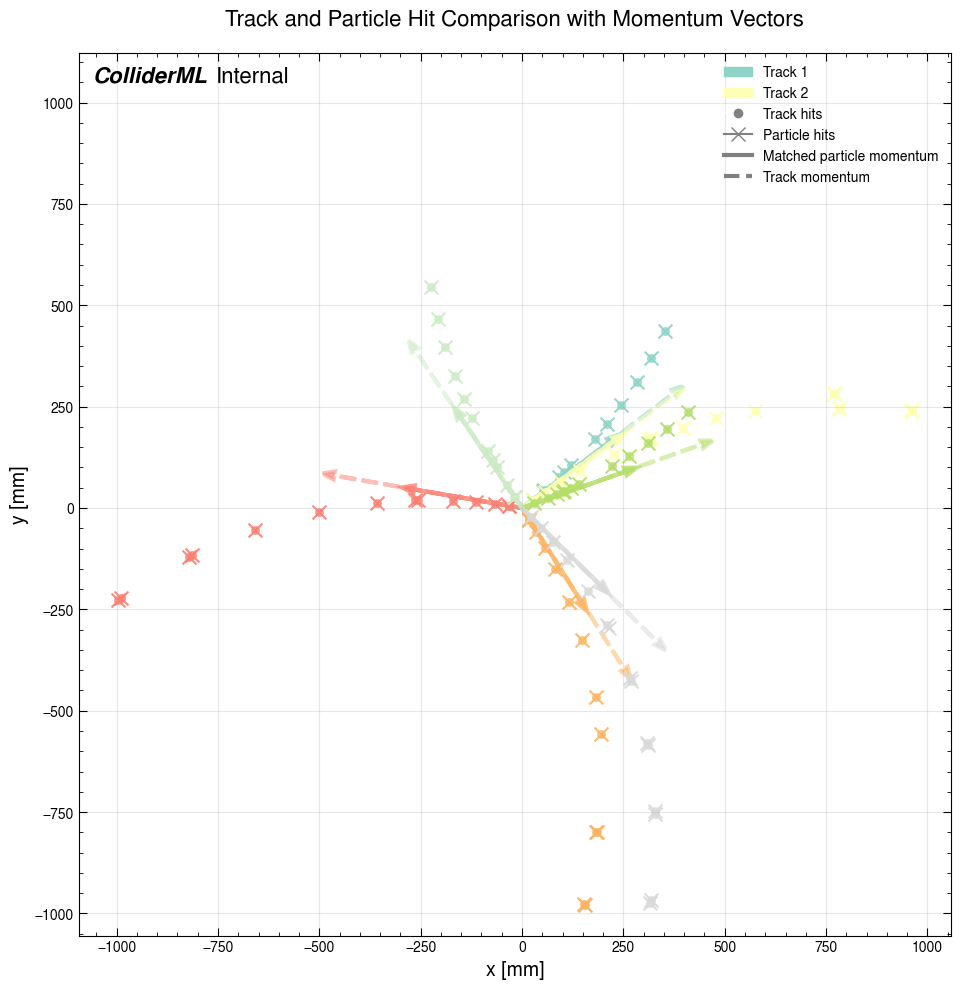

In [22]:
import matplotlib.patches as mpatches

plt.figure(figsize=(10, 10))
num_tracks_to_sample = 7

# Randomly sample track indices
track_indices = np.random.choice(len(parquet_tracks_df), size=min(num_tracks_to_sample, len(parquet_tracks_df)), replace=False)

# Use a pleasant colormap with more colors
cmap = plt.cm.Set3  # Set3 provides 12 distinct, pleasant colors
colors = [cmap(i / num_tracks_to_sample) for i in range(num_tracks_to_sample)]

legend_elements = []

for idx, track_idx in enumerate(track_indices):
    # Plot the track hits
    track_hit_ids = parquet_track_hits_df.iloc[track_idx].hit_ids
    track_scatter = plt.scatter(parquet_trackerhits_df.x.iloc[track_hit_ids], parquet_trackerhits_df.y.iloc[track_hit_ids], 
                               marker='o', color=colors[idx], s=30, alpha=0.7, 
                               label=f'Track {idx+1} hits')

    # Get the majority particle id for the track
    majority_particle_id = parquet_tracks_df.iloc[track_idx]['majority_particle_id']

    # Get the hit ids for the majority particle id
    majority_particle_hit_ids = parquet_trackerhits_df[parquet_trackerhits_df.particle_id == majority_particle_id].index.tolist()
    particle_scatter = plt.scatter(parquet_trackerhits_df.x.iloc[majority_particle_hit_ids], parquet_trackerhits_df.y.iloc[majority_particle_hit_ids], 
                                  marker='x', color=colors[idx], s=100, alpha=0.9,
                                  label=f'Particle {idx+1} hits')
    
    # Plot the phi vector of the particle as an arrow (solid arrow)
    particle_entry = parquet_particles_df[parquet_particles_df['particle_id'] == majority_particle_id].iloc[0]
    normalised_momentum_vector = particle_entry[['px', 'py']].values / np.linalg.norm(particle_entry[['px', 'py']].values)*300
    particle_arrow = plt.arrow(particle_entry['vx'], particle_entry['vy'], normalised_momentum_vector[0], normalised_momentum_vector[1], 
              color=colors[idx], head_width=20, head_length=30, length_includes_head=True, alpha=0.8, linewidth=3)
    phi = np.arctan2(particle_entry['py'], particle_entry['px'])

    # Plot the phi vector of the track (dashed arrow)
    track_entry = parquet_tracks_df.iloc[track_idx]
    phi = track_entry['phi']
    
    # Convert phi to px, py components (assuming unit momentum for visualization)
    track_px = np.cos(phi) * 500  # scale for visualization
    track_py = np.sin(phi) * 500
    
    # Plot from origin (assuming tracks start from origin for visualization)
    track_arrow = plt.arrow(0, 0, track_px, track_py, color=colors[idx], head_width=20, head_length=30, 
              length_includes_head=True, alpha=0.5, linewidth=3, linestyle='--')

# Create custom legend elements
legend_elements = [
    mpatches.Patch(color=colors[0], label='Track 1'),
    mpatches.Patch(color=colors[1], label='Track 2'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=8, label='Track hits'),
    plt.Line2D([0], [0], marker='x', color='gray', markerfacecolor='gray', markersize=10, label='Particle hits'),
    plt.Line2D([0], [0], color='gray', linewidth=3, label='Matched particle momentum'),
    plt.Line2D([0], [0], color='gray', linewidth=3, linestyle='--', label='Track momentum')
]

plt.legend(handles=legend_elements, loc='upper right', frameon=True, fancybox=True, shadow=True)

plt.xlabel('x [mm]', fontsize=14)
plt.ylabel('y [mm]', fontsize=14)
plt.title('Track and Particle Hit Comparison with Momentum Vectors', fontsize=16, pad=20)

# Add ATLAS label
atl.atlasify("Internal")

plt.grid(True, alpha=0.3)
plt.gca().set_aspect('equal', 'box')
plt.tight_layout()
plt.show()


## EDM4HEP Version

In [8]:
run_size = 128
run_id = global_event_id // run_size
local_event = global_event_id % run_size

In [25]:
edm4hep_file = f"/global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup/ttbar/v1/runs/{run_id}/edm4hep.root"
edm4hep_event = EDM4hepEventBatch(str(edm4hep_file), events=(local_event, local_event+1), condense_calo=False)

2025-10-31 02:12:34,945 - DEBUG - pyedm4hep.event_batch - EDM4hepEventBatch init: file=/global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup/ttbar/v1/runs/0/edm4hep.root, events=(0, 1), full_load=False, condense_calo=False


In [26]:
edm4hep_trackerhits_df = edm4hep_event.get_tracker_hits_df()
edm4hep_calohits_df = edm4hep_event.get_calo_hits_df()
edm4hep_contributions_df = edm4hep_event.get_calo_contributions_df()
edm4hep_particles_df = edm4hep_event.get_particles_df()

2025-10-31 02:12:43,226 - DEBUG - pyedm4hep.event_batch - _load_tracker_hits: start=0, stop=1
2025-10-31 02:12:43,228 - DEBUG - asyncio - Using selector: EpollSelector
2025-10-31 02:12:43,465 - DEBUG - pyedm4hep.event_batch - tracker PixelBarrelReadout: rows=43967 cols=['event_id', 'subentry', 'cellID', 'time', 'x', 'y', 'z', 'detector']
2025-10-31 02:12:43,570 - DEBUG - pyedm4hep.event_batch - tracker PixelEndcapReadout: rows=40995 cols=['event_id', 'subentry', 'cellID', 'time', 'x', 'y', 'z', 'detector']
2025-10-31 02:12:43,694 - DEBUG - pyedm4hep.event_batch - tracker ShortStripBarrelReadout: rows=45304 cols=['event_id', 'subentry', 'cellID', 'time', 'x', 'y', 'z', 'detector']
2025-10-31 02:12:43,803 - DEBUG - pyedm4hep.event_batch - tracker ShortStripEndcapReadout: rows=40931 cols=['event_id', 'subentry', 'cellID', 'time', 'x', 'y', 'z', 'detector']
2025-10-31 02:12:44,001 - DEBUG - pyedm4hep.event_batch - tracker LongStripBarrelReadout: rows=19707 cols=['event_id', 'subentry', 'ce

Any NAN values:  event_id       False
subentry       False
energy         False
time           False
particle_id    False
detector       False
hit_index      False
cellID         False
x              False
y              False
z              False
dtype: bool


2025-10-31 02:12:49,405 - DEBUG - pyedm4hep.event_batch - _load_particles_and_links: start=0, stop=1
2025-10-31 02:12:49,562 - DEBUG - pyedm4hep.event_batch - particles columns after rename: ['event_id', 'subentry', 'PDG', 'simulatorStatus', 'charge', 'time', 'mass', 'vx', 'vy', 'vz', 'px', 'py', 'pz', 'parents_begin', 'parents_end'] rows=184995
2025-10-31 02:12:49,562 - INFO - pyedm4hep.event_batch -   ↳ particles loaded: 0.1566s (184995 rows)
2025-10-31 02:12:49,600 - INFO - pyedm4hep.event_batch -   ↳ links loaded: 0.0340s (parents=325032, daughters=0)
2025-10-31 02:12:49,600 - INFO - pyedm4hep.event_batch - ⏱️  _load_particles_and_links: 0.5467s total
2025-10-31 02:12:49,601 - DEBUG - pyedm4hep.event_batch - augment_particles: input particles rows=184995, cols=['event_id', 'subentry', 'PDG', 'simulatorStatus', 'charge', 'time', 'mass', 'vx', 'vy', 'vz', 'px', 'py', 'pz', 'parents_begin', 'parents_end', 'vr', 'energy', 'kinetic_energy']
2025-10-31 02:12:49,601 - DEBUG - pyedm4hep.ev

In [36]:
edm4hep_particles_df

,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,pz,parents_begin,parents_end,vr,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits
0,0,0,2212,0,1.000000,0.000000,0.938270,0.000000,0.000000,0.000000,...,6999.999937,0,0,0.000000,7000.000000,6999.061730,0,False,0,0
1,0,1,1,0,-0.333333,-0.221602,0.000000,-0.011325,-0.007458,116.524419,...,855.719020,0,1,0.013560,855.719020,855.719020,1,False,0,0
2,0,2,2,0,0.666667,-0.221602,0.330000,-0.011325,-0.007458,116.524419,...,1052.295476,1,2,0.013560,1052.295527,1051.965527,2,False,0,0
3,0,3,2103,0,0.333333,-0.221602,0.771330,-0.011325,-0.007458,116.524419,...,2005.069087,2,3,0.013560,2005.069235,2004.297905,3,False,0,0
4,0,4,-1,0,0.333333,-0.221602,0.330000,-0.011325,-0.007458,116.524419,...,3086.916278,3,4,0.013560,3086.916295,3086.586295,4,False,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
184990,0,184990,11,1493172224,-1.000000,201.315033,0.000511,-664.198338,-473.025016,-111.586509,...,-0.000571,325027,325028,815.421424,0.000778,0.000267,184990,True,2,0
184991,0,184991,-211,1157627904,-1.000000,10.572216,0.139570,141.049083,-641.556780,3264.950226,...,0.121737,325028,325029,656.878943,0.502607,0.363037,184991,True,0,109
184992,0,184992,11,1426063360,-1.000000,11.322639,0.000511,-56.644220,-625.888371,3296.896898,...,-0.093238,325029,325030,628.446355,0.187757,0.187246,184992,True,0,87
184993,0,184993,11,1426063360,-1.000000,10.347099,0.000511,175.211539,-629.577965,3216.613171,...,0.168845,325030,325031,653.504015,0.287490,0.286979,184993,True,0,48


In [27]:
edm4hep_trackerhits_df

,event_id,subentry,cellID,time,x,y,z,detector,particle_id,r,R,phi,theta,eta
0,0,0,6931398611241990,3.222315,0.668716,-32.106328,-89.063451,PixelBarrelReadout,75387,32.113292,94.676089,-1.549971,2.795536,-1.744249
1,0,1,71266396637698070,3.793618,5.013834,-67.582397,-255.976585,PixelBarrelReadout,75387,67.768126,264.795263,-1.496744,2.882787,-2.039220
2,0,2,68098652098468118,3.824599,5.337656,-69.484042,-265.025765,PixelBarrelReadout,75387,69.688756,274.034996,-1.494128,2.884463,-2.045789
3,0,3,71424490088704038,4.536655,15.964708,-112.813853,-473.046001,PixelBarrelReadout,75387,113.937866,486.574102,-1.430216,2.905235,-2.130884
4,0,4,70122539472718854,3.304400,0.784387,-32.092381,-114.241075,PixelBarrelReadout,75383,32.101965,118.665746,-1.546360,2.867655,-1.981721
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
214903,0,23999,16767552471102,17.490334,-29.307426,-794.268661,2245.500000,LongStripEndcapReadout,184982,794.809179,2382.014249,-1.607678,0.340195,1.761673
214904,0,24000,16698834042942,17.526642,-30.696604,-793.978401,2240.500000,LongStripEndcapReadout,184982,794.571572,2377.221957,-1.609439,0.340803,1.759854
214905,0,24001,412318052398,20.173454,-113.754037,-743.231957,1879.500000,LongStripEndcapReadout,184982,751.886775,2024.315680,-1.722671,0.380546,1.647124
214906,0,24002,519691186222,20.210278,-114.625410,-742.158668,1874.500000,LongStripEndcapReadout,184982,750.958370,2019.328780,-1.724034,0.381039,1.645798


In [28]:
parquet_trackerhits_df

,event_id,x,y,z,true_x,true_y,true_z,time,particle_id,cell_id,detector,volume_id,layer_id,surface_id
0,0,47.325001,7.075000,-1515.599976,47.337048,7.095499,-1515.599976,-5.113974,18989,16982300688487,1,16,4,1
1,0,52.175003,-7.475000,-1515.599976,52.155815,-7.469731,-1515.599976,-5.106862,156787,639950127207,1,16,4,1
2,0,60.924999,-9.225000,-1515.599976,60.942432,-9.218755,-1515.599976,-5.101593,156799,790273982567,1,16,4,1
3,0,77.432602,6.575000,-1515.599976,77.440285,6.574460,-1515.599976,-5.063385,157055,17029545328743,1,16,4,1
4,0,68.925003,6.325000,-1515.599976,68.924652,6.306347,-1515.599976,-5.001588,156758,17051020165223,1,16,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
214898,0,349.984802,925.928772,3009.500000,350.761627,927.832886,3009.562012,19.148195,94004,16707423867230,5,30,12,192
214899,0,342.999695,928.659790,3009.500000,344.041565,931.297058,3009.403076,20.213150,184096,16488380535134,5,30,12,192
214900,0,430.662811,894.385986,3009.500000,434.833649,905.190613,3009.500000,26.139853,83512,1589138985310,5,30,12,192
214901,0,340.322083,929.706665,3009.500000,347.662811,948.423645,3009.390137,68.022552,128451,16406776156510,5,30,12,192


In [29]:
df1 = edm4hep_trackerhits_df[["x", "y", "z"]].astype(np.float32)
df2 = parquet_trackerhits_df[["true_x", "true_y", "true_z"]].astype(np.float32)
df1.columns = ["x", "y", "z"]
df2.columns = ["x", "y", "z"]
merged_hits = df1.merge(df2, on=["x", "y", "z"], how="inner")
print(f"{len(merged_hits)} out of {len(edm4hep_trackerhits_df)} hits match within tolerance.")

214905 out of 214908 hits match within tolerance.


In [30]:
# Test vx, vy, vz (_x and _y are the same)
merged_particles = parquet_particles_df.merge(edm4hep_particles_df, on="particle_id", how="inner", suffixes=("_parquet", "_edm4hep"))
df1 = merged_particles[["vx_parquet", "vy_parquet", "vz_parquet", "px_parquet", "py_parquet", "pz_parquet"]].astype(np.float32)
df2 = merged_particles[["vx_edm4hep", "vy_edm4hep", "vz_edm4hep", "px_edm4hep", "py_edm4hep", "pz_edm4hep"]].astype(np.float32)
df1.columns = ["vx", "vy", "vz", "px", "py", "pz"]
df2.columns = ["vx", "vy", "vz", "px", "py", "pz"]
comparison = (df1 - df2).abs() < 1e-4  # adjust tolerance if needed
comparison_all = comparison.all(axis=1)
print(f"{comparison_all.sum()} out of {len(comparison_all)} particles match within tolerance.")

# Optionally, show where mismatches occur
if not comparison_all.all():
    mismatches = pd.concat([df1[~comparison_all], df2[~comparison_all]], axis=1, keys=["edm4hep", "parquet"])
    print("Mismatching particles:")
    delta = merged_particles[f"{col}_parquet"] - merged_particles[f"{col}_edm4hep"]
    print(f"Max delta: {delta.abs().max()}")
    print("\n")

149947 out of 149947 particles match within tolerance.


In [33]:
merged_particles.columns

Index(['event_id_parquet', 'particle_id', 'pdg_id', 'mass_parquet',
       'energy_parquet', 'charge_parquet', 'vx_parquet', 'vy_parquet',
       'vz_parquet', 'time_parquet', 'px_parquet', 'py_parquet', 'pz_parquet',
       'vertex_primary', 'parent_id', 'num_tracker_hits_parquet',
       'event_id_edm4hep', 'subentry', 'PDG', 'simulatorStatus',
       'charge_edm4hep', 'time_edm4hep', 'mass_edm4hep', 'vx_edm4hep',
       'vy_edm4hep', 'vz_edm4hep', 'px_edm4hep', 'py_edm4hep', 'pz_edm4hep',
       'parents_begin', 'parents_end', 'vr', 'energy_edm4hep',
       'kinetic_energy', 'created_in_simulation', 'num_tracker_hits_edm4hep',
       'num_calo_hits'],
      dtype='object')

In [39]:
# Check that all generator particles are present from the edm4hep collection
edm4hep_generator_particles = edm4hep_particles_df[edm4hep_particles_df.created_in_simulation == False]
parquet_generator_particles = merged_particles[merged_particles.created_in_simulation == False]
print(f"Number of generator particles in edm4hep: {len(edm4hep_generator_particles)}")
print(f"Number of generator particles in parquet: {len(parquet_generator_particles)}")

edm4hep_particles_with_hits = edm4hep_particles_df[(edm4hep_particles_df.num_tracker_hits > 0) | (edm4hep_particles_df.num_calo_hits > 0)]
parquet_particles_with_hits = merged_particles[(merged_particles.num_tracker_hits_edm4hep > 0) | (merged_particles.num_calo_hits > 0)]
print(f"Number of particles with hits in edm4hep: {len(edm4hep_particles_with_hits)}")
print(f"Number of particles with hits in parquet: {len(parquet_particles_with_hits)}")


Number of generator particles in edm4hep: 75494
Number of generator particles in parquet: 40446
Number of particles with hits in edm4hep: 114076
Number of particles with hits in parquet: 114076


In [41]:
# Cast all x,y,z to float32
parquet_calohits_df = parquet_calohits_df.astype({"x": np.float32, "y": np.float32, "z": np.float32})
edm4hep_calohits_df = edm4hep_calohits_df.astype({"x": np.float32, "y": np.float32, "z": np.float32})
merged_calo = parquet_calohits_df.merge(edm4hep_calohits_df, on=["x", "y", "z"], how="inner")
print(f"Parqet has {len(parquet_calohits_df)} calo hits, EDM4hep has {len(edm4hep_calohits_df)} calo hits.")
print(f"{len(merged_calo)} out of {len(edm4hep_calohits_df)} calo hits match within tolerance.")

Parqet has 396223 calo hits, EDM4hep has 1073103 calo hits.
396223 out of 1073103 calo hits match within tolerance.


## HepMC Version

#### Hard Scatter

In [42]:
hepmc_hs_file = f"/global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup/ttbar/v1/runs/{run_id}/events.hepmc"

In [43]:
root_file = uproot.open(edm4hep_file)["events"]

In [44]:
hepmc_event_number = root_file["EventHeader/EventHeader.eventNumber"].arrays()[local_event]["EventHeader.eventNumber"].tolist()[0]
print(f"HepMC event number: {hepmc_event_number}")

HepMC event number: 0


In [45]:
hepmc_event_number

0

In [46]:
with hep.open(str(hepmc_hs_file)) as f:
    for i, evt in enumerate(f):
        if evt.event_number == hepmc_event_number:
            hepmc_hs_event = evt
            break

In [47]:
hepmc_hs_momentum_df = pd.DataFrame(
    {
        "px": hepmc_hs_event.numpy.particles.px,
        "py": hepmc_hs_event.numpy.particles.py,
        "pz": hepmc_hs_event.numpy.particles.pz
    }
).astype(np.float32)
hepmc_hs_momentum_df

,px,py,pz
0,0.000000e+00,0.000000,7000.000000
1,-5.048710e-29,0.000000,855.718994
2,0.000000e+00,0.000000,1052.295532
3,0.000000e+00,0.000000,2005.069092
4,0.000000e+00,0.000000,3086.916260
...,...,...,...
539,-1.871418e+00,0.137764,-57.606289
540,2.190929e-01,0.819140,-9.985355
541,1.081709e+00,3.834896,-16.791241
542,2.221538e-01,0.738183,-9.102931


In [49]:
merged_particles.columns

Index(['event_id_parquet', 'particle_id', 'pdg_id', 'mass_parquet',
       'energy_parquet', 'charge_parquet', 'vx_parquet', 'vy_parquet',
       'vz_parquet', 'time_parquet', 'px_parquet', 'py_parquet', 'pz_parquet',
       'vertex_primary', 'parent_id', 'num_tracker_hits_parquet',
       'event_id_edm4hep', 'subentry', 'PDG', 'simulatorStatus',
       'charge_edm4hep', 'time_edm4hep', 'mass_edm4hep', 'vx_edm4hep',
       'vy_edm4hep', 'vz_edm4hep', 'px_edm4hep', 'py_edm4hep', 'pz_edm4hep',
       'parents_begin', 'parents_end', 'vr', 'energy_edm4hep',
       'kinetic_energy', 'created_in_simulation', 'num_tracker_hits_edm4hep',
       'num_calo_hits'],
      dtype='object')

In [50]:
hs_merged_particles = merged_particles[merged_particles.vertex_primary == 1]
hs_generator_particles = hs_merged_particles[hs_merged_particles.created_in_simulation == False].astype({"px_parquet": np.float32, "py_parquet": np.float32, "pz_parquet": np.float32})

In [53]:
hepmc_hs_momentum_df.drop_duplicates(subset=["px", "py", "pz"], inplace=True)
hs_generator_particles.drop_duplicates(subset=["px_parquet", "py_parquet", "pz_parquet"], inplace=True)


In [54]:
print(f"There are {len(hepmc_hs_momentum_df)} particles in the HEPMC hard scatter event")
print(f"There are {len(hs_generator_particles)} generator particles in the EDM4hep hard scatter event")

# Exact float32 precision overlap
merged_hepmc_parquet_hs = hepmc_hs_momentum_df.merge(
    hs_generator_particles, 
    left_on=["px", "py", "pz"], 
    right_on=["px_parquet", "py_parquet", "pz_parquet"], 
    how="inner"
)
print(f"There are {len(merged_hepmc_parquet_hs)} particles in the HEPMC hard scatter event that are PERFECTLY (float32 precision) in the parquet hard scatter event")

# Now overlap within 0.1% and 1% relative difference
def get_presence_count(hs_gen_df, hepmc_df, threshold):
    hs_px = hs_gen_df["px_parquet"].values
    hs_py = hs_gen_df["py_parquet"].values
    hs_pz = hs_gen_df["pz_parquet"].values
    hepmc_px = hepmc_df["px"].values
    hepmc_py = hepmc_df["py"].values
    hepmc_pz = hepmc_df["pz"].values

    count = 0
    for i in range(len(hs_gen_df)):
        # Compute relative differences
        px_diff = np.abs(hs_px[i] - hepmc_px) / np.clip(np.abs(hs_px[i]), 1e-10, None)
        py_diff = np.abs(hs_py[i] - hepmc_py) / np.clip(np.abs(hs_py[i]), 1e-10, None)
        pz_diff = np.abs(hs_pz[i] - hepmc_pz) / np.clip(np.abs(hs_pz[i]), 1e-10, None)
        mean_diff = (px_diff + py_diff + pz_diff) / 3.0
        # If *any* of the differences for this particle is below threshold, count as present
        if np.any(mean_diff < threshold):
            count += 1
    return count

count_0p1 = get_presence_count(hs_generator_particles, hepmc_hs_momentum_df, 0.001)
count_1 = get_presence_count(hs_generator_particles, hepmc_hs_momentum_df, 0.01)

print(f"There are {count_0p1} generator particles in the HEPMC hard scatter event that match to a HEPMC particle within 0.1% relative mean (px/py/pz) difference")
print(f"There are {count_1} generator particles in the HEPMC hard scatter event that match to a HEPMC particle within 1% relative mean (px/py/pz) difference")



There are 448 particles in the HEPMC hard scatter event
There are 253 generator particles in the EDM4hep hard scatter event
There are 137 particles in the HEPMC hard scatter event that are PERFECTLY (float32 precision) in the parquet hard scatter event
There are 242 generator particles in the HEPMC hard scatter event that match to a HEPMC particle within 0.1% relative mean (px/py/pz) difference
There are 246 generator particles in the HEPMC hard scatter event that match to a HEPMC particle within 1% relative mean (px/py/pz) difference


In [110]:
# Get those hs_generator_particles that are not in the merged_hepmc_parquet_hs
missing_particles = hs_generator_particles[~hs_generator_particles.particle_id.isin(merged_hepmc_parquet_hs.particle_id)]
missing_particles


,event_id_parquet,particle_id,pdg_id,mass_parquet,energy_parquet,charge_parquet,vx_parquet,vy_parquet,vz_parquet,time_parquet,...,py_edm4hep,pz_edm4hep,parents_begin,parents_end,vr,energy_edm4hep,kinetic_energy,created_in_simulation,num_tracker_hits_edm4hep,num_calo_hits_edm4hep
88,3,264,-20213,1.25228,26.531042,-1.0,-2.832186,1.496297,65.774239,-8.730561,...,10.425018,3.330504,1017,1018,3.203152,26.531042,25.278762,False,0,0
89,3,265,421,1.86486,39.079671,0.0,-2.832186,1.496297,65.774239,-8.730561,...,19.955536,4.927957,1018,1019,3.203152,39.079671,37.214811,False,0,0
90,3,266,211,0.13957,0.720156,1.0,-0.014461,0.002710,65.368271,-8.741320,...,0.007517,0.094854,1019,1020,0.014713,0.720156,0.580586,False,15,74
91,3,267,-211,0.13957,1.165974,-1.0,-0.014461,0.002710,65.368271,-8.741320,...,0.490930,0.264934,1020,1021,0.014713,1.165974,1.026404,False,12,0
92,3,268,111,0.13498,0.307625,0.0,-0.014461,0.002710,65.368271,-8.741320,...,-0.071673,-0.022168,1021,1022,0.014713,0.307625,0.172645,False,0,52
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
230,3,423,-321,0.49368,21.511911,-1.0,-0.014461,0.002710,65.368271,-8.741320,...,-7.288554,-19.683072,1228,1229,0.014713,21.511911,21.018231,False,15,1687
231,3,424,111,0.13498,1.573532,0.0,-0.014461,0.002710,65.368271,-8.741320,...,-0.603373,-1.429559,1229,1230,0.014713,1.573532,1.438552,False,0,0
232,3,425,211,0.13957,0.913562,1.0,-0.014461,0.002710,65.368271,-8.741320,...,-0.031996,-0.901805,1230,1231,0.014713,0.913562,0.773992,False,5,0
233,3,426,111,0.13498,3.334236,0.0,-0.014461,0.002710,65.368271,-8.741320,...,-1.316398,-2.987325,1231,1232,0.014713,3.334236,3.199256,False,0,0


In [55]:
for i in merged_particles.vertex_primary.unique():
    hs_merged_particles = merged_particles[merged_particles.vertex_primary == i]
    hs_generator_particles = hs_merged_particles[hs_merged_particles.created_in_simulation == False].astype({"px_parquet": np.float32, "py_parquet": np.float32, "pz_parquet": np.float32})
    print(f"There are {len(hs_generator_particles)} generator particles in the HEPMC hard scatter event for vertex primary {i}")
    merged_hepmc_parquet_hs = hepmc_hs_momentum_df.merge(hs_generator_particles, left_on=["px", "py", "pz"], right_on=["px_parquet", "py_parquet", "pz_parquet"], how="inner")
    print(f"There are {len(merged_hepmc_parquet_hs)} particles in the HEPMC hard scatter event that are also in the parquet hard scatter event for vertex primary {i}")
    

There are 261 generator particles in the HEPMC hard scatter event for vertex primary 1
There are 137 particles in the HEPMC hard scatter event that are also in the parquet hard scatter event for vertex primary 1
There are 511 generator particles in the HEPMC hard scatter event for vertex primary 2
There are 0 particles in the HEPMC hard scatter event that are also in the parquet hard scatter event for vertex primary 2
There are 225 generator particles in the HEPMC hard scatter event for vertex primary 3
There are 0 particles in the HEPMC hard scatter event that are also in the parquet hard scatter event for vertex primary 3
There are 268 generator particles in the HEPMC hard scatter event for vertex primary 4
There are 0 particles in the HEPMC hard scatter event that are also in the parquet hard scatter event for vertex primary 4
There are 267 generator particles in the HEPMC hard scatter event for vertex primary 5
There are 0 particles in the HEPMC hard scatter event that are also in 

In [62]:
edm4hep_generator_particles.astype({"px": np.float32, "py": np.float32, "pz": np.float32}).merge(hepmc_momentum_df, on=["px", "py", "pz"], how="inner")

,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,pz,parents_begin,parents_end,vr,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits
0,3,0,2212,0,1.000000,0.00000,0.93827,0.000000,0.00000,0.000000,...,7000.000000,0,0,0.000000,7000.000000,6999.061730,0,False,0,0
1,3,1,21,0,0.000000,-8.74132,0.00000,-0.014461,0.00271,65.368268,...,133.251007,0,1,0.014713,133.251010,133.251010,1,False,0,0
2,3,2,2101,0,0.333333,-8.74132,0.57933,-0.014461,0.00271,65.368268,...,1491.666626,1,2,0.014713,1491.666755,1491.087425,2,False,0,0
3,3,2,2101,0,0.333333,-8.74132,0.57933,-0.014461,0.00271,65.368268,...,1491.666626,1,2,0.014713,1491.666755,1491.087425,2,False,0,0
4,3,3,2,0,0.666667,-8.74132,0.33000,-0.014461,0.00271,65.368268,...,5375.082031,2,3,0.014713,5375.082213,5374.752213,3,False,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
830,3,77990,2212,0,1.000000,0.00000,0.93827,0.000000,0.00000,0.000000,...,-7000.000000,220219,220219,0.000000,7000.000000,6999.061730,77990,False,0,0
831,3,77992,2212,0,1.000000,0.00000,0.93827,0.000000,0.00000,0.000000,...,7000.000000,220220,220220,0.000000,7000.000000,6999.061730,77992,False,0,0
832,3,78010,2212,0,1.000000,0.00000,0.93827,0.000000,0.00000,0.000000,...,-7000.000000,220237,220237,0.000000,7000.000000,6999.061730,78010,False,0,0
833,3,79667,2212,0,1.000000,0.00000,0.93827,0.000000,0.00000,0.000000,...,7000.000000,224120,224120,0.000000,7000.000000,6999.061730,79667,False,0,0


#### Full Pileup

In [71]:
hepmc_full_file = f"/global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup/ttbar/v1/runs/{run_id}/merged_events.hepmc3"

In [72]:
root_file = uproot.open(edm4hep_file)["events"]

In [73]:
hepmc_event_number = root_file["EventHeader/EventHeader.eventNumber"].arrays()[local_event]["EventHeader.eventNumber"].tolist()[0]
print(f"HepMC event number: {hepmc_event_number}")

HepMC event number: 6


In [75]:
with hep.open(str(hepmc_full_file)) as f:
    for i, evt in tqdm(enumerate(f)):
        if evt.event_number == hepmc_event_number:
            hepmc_event = evt
            break
hepmc_event

6it [02:53, 28.90s/it]


<GenEvent momentum_unit=1, length_unit=0, event_number=6, particles=79824, vertices=44999, run_info=GenRunInfo(tools=[], weight_names=[], attributes={})>

In [78]:
hepmc_momentum_df = pd.DataFrame(
    {
        "px": hepmc_event.numpy.particles.px,
        "py": hepmc_event.numpy.particles.py,
        "pz": hepmc_event.numpy.particles.pz
    }
).astype(np.float32)
hepmc_momentum_df

,px,py,pz
0,0.000000e+00,0.000000,7000.000000
1,2.524355e-29,0.000000,133.251007
2,0.000000e+00,0.000000,1491.666626
3,0.000000e+00,0.000000,5375.082031
4,0.000000e+00,0.000000,-7000.000000
...,...,...,...
79819,1.116357e-02,-0.135746,45.074371
79820,3.582450e-02,0.052216,32.843372
79821,-9.196015e-02,0.057574,117.575775
79822,1.281384e-01,0.047196,2.583763


In [111]:
check_missing_particles = missing_particles.merge(hepmc_momentum_df, left_on=["px_parquet", "py_parquet", "pz_parquet"], right_on=["px", "py", "pz"], how="inner")
check_missing_particles

,event_id_parquet,particle_id,pdg_id,mass_parquet,energy_parquet,charge_parquet,vx_parquet,vy_parquet,vz_parquet,time_parquet,...,parents_end,vr,energy_edm4hep,kinetic_energy,created_in_simulation,num_tracker_hits_edm4hep,num_calo_hits_edm4hep,px,py,pz


## Comprehensive Multi-Event Validation

Systematically check all 128 events in the run to validate that primary vertex 1 matches the hard scatter HepMC file.

In [9]:
edm4hep_file = f"/global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup/ttbar/v1/runs/{run_id}/edm4hep.root"
# Step 1: Load EDM4hep file for all 128 events in the run
print(f"Loading EDM4hep file: {edm4hep_file}")
print(f"Processing run_id: {run_id}, which contains events 0-127")

# Load all events at once
edm4hep_batch_all = EDM4hepEventBatch(str(edm4hep_file), events=(0, 128), condense_calo=False)

2025-10-31 05:58:47,835 - DEBUG - pyedm4hep.event_batch - EDM4hepEventBatch init: file=/global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup/ttbar/v1/runs/0/edm4hep.root, events=(0, 128), full_load=False, condense_calo=False


Loading EDM4hep file: /global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup/ttbar/v1/runs/0/edm4hep.root
Processing run_id: 0, which contains events 0-127


In [10]:
hepmc_hs_file = f"/global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup/ttbar/v1/runs/{run_id}/events.hepmc"
# Step 2: Pre-load all HepMC hard scatter events into a list
print(f"\nLoading HepMC hard scatter file: {hepmc_hs_file}")
hepmc_hs_events_list = []

with hep.open(str(hepmc_hs_file)) as f:
    for evt in tqdm(f, desc="Loading HepMC events"):
        hepmc_hs_events_list.append(evt)

print(f"Loaded {len(hepmc_hs_events_list)} events from HepMC hard scatter file")

# Create a dictionary mapping event_number to event for fast lookup
hepmc_hs_dict = {evt.event_number: evt for evt in hepmc_hs_events_list}
print(f"Created lookup dictionary with {len(hepmc_hs_dict)} unique event numbers")


Loading HepMC hard scatter file: /global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup/ttbar/v1/runs/0/events.hepmc


Loading HepMC events: 128it [00:00, 409.79it/s]

Loaded 128 events from HepMC hard scatter file
Created lookup dictionary with 128 unique event numbers


In [11]:
# Step 3: Extract event header information from ROOT file
root_tree = uproot.open(edm4hep_file)["events"]
event_numbers_array = root_tree["EventHeader/EventHeader.eventNumber"].arrays()

# Build a list of event numbers for each local event index
event_number_mapping = []
for local_evt_idx in range(128):
    evt_num = event_numbers_array[local_evt_idx]["EventHeader.eventNumber"].tolist()[0]
    event_number_mapping.append(evt_num)

print(f"Built event number mapping for 128 events")
print(f"First few mappings: {event_number_mapping[:5]}")

2025-10-31 05:58:51,095 - DEBUG - asyncio - Using selector: EpollSelector


Built event number mapping for 128 events
First few mappings: [0, 3, 2, 6, 4]


In [ ]:
# Step 4: Main validation loop - check all events
validation_results = []
parquet_particles = load_all_particles_parquet(particles_file)

print("\nStarting validation loop across all 128 events...")

for local_event_idx in tqdm(parquet_particles.event_id.unique(), desc="Validating events"):
    # Calculate global event ID
    global_evt_id = run_id * 128 + local_event_idx
    
    # Get the HepMC event number from the header
    hepmc_evt_num = event_number_mapping[local_event_idx]
    
    # Load parquet data for this event
    try:
        local_parquet_particles = parquet_particles[parquet_particles['event_id'] == local_event_idx]
        if local_parquet_particles.empty:
            validation_results.append({
                'local_event': local_event_idx,
                'global_event': global_evt_id,
                'hepmc_event_number': hepmc_evt_num,
                'status': 'EMPTY_PARQUET',
                'num_parquet_hs_gen': 0,
                'num_hepmc_hs_gen': 0,
                'num_matched_perfect': 0,
                'num_matched_0p1pct': 0,
                'num_matched_1pct': 0
            })
            continue
            
        # Get EDM4hep particles for this event (from the batch)
        edm4hep_particles = edm4hep_batch_all.get_particles_df()
        edm4hep_particles_evt = edm4hep_particles[edm4hep_particles['event_id'] == local_event_idx]
        
        # Merge parquet and edm4hep data
        merged = local_parquet_particles.merge(
            edm4hep_particles_evt, 
            on="particle_id", 
            how="inner", 
            suffixes=("_parquet", "_edm4hep")
        )
        
        # Filter for primary vertex (hard scatter) generator particles
        hs_merged = merged[merged.vertex_primary == 1]
        hs_gen_particles = hs_merged[hs_merged.created_in_simulation == False].astype({
            "px_parquet": np.float32, 
            "py_parquet": np.float32, 
            "pz_parquet": np.float32
        })
        
        # Get HepMC hard scatter event
        if hepmc_evt_num not in hepmc_hs_dict:
            validation_results.append({
                'local_event': local_event_idx,
                'global_event': global_evt_id,
                'hepmc_event_number': hepmc_evt_num,
                'status': 'HEPMC_NOT_FOUND',
                'num_parquet_hs_gen': len(hs_gen_particles),
                'num_hepmc_hs_gen': 0,
                'num_matched_perfect': 0,
                'num_matched_0p1pct': 0,
                'num_matched_1pct': 0
            })
            continue
            
        hepmc_hs_evt = hepmc_hs_dict[hepmc_evt_num]
        hepmc_hs_mom_df = pd.DataFrame({
            "px": hepmc_hs_evt.numpy.particles.px,
            "py": hepmc_hs_evt.numpy.particles.py,
            "pz": hepmc_hs_evt.numpy.particles.pz
        }).astype(np.float32)
        
        # Remove duplicates
        hepmc_hs_mom_df_unique = hepmc_hs_mom_df.drop_duplicates(subset=["px", "py", "pz"])
        hs_gen_particles_unique = hs_gen_particles.drop_duplicates(subset=["px_parquet", "py_parquet", "pz_parquet"])
        
        # Perfect match (float32 precision)
        merged_perfect = hepmc_hs_mom_df_unique.merge(
            hs_gen_particles_unique,
            left_on=["px", "py", "pz"],
            right_on=["px_parquet", "py_parquet", "pz_parquet"],
            how="inner"
        )
        
        # Fuzzy matching with thresholds
        def count_matches(hs_gen_df, hepmc_df, threshold):
            if len(hs_gen_df) == 0 or len(hepmc_df) == 0:
                return 0
            hs_px = hs_gen_df["px_parquet"].values
            hs_py = hs_gen_df["py_parquet"].values
            hs_pz = hs_gen_df["pz_parquet"].values
            hepmc_px = hepmc_df["px"].values
            hepmc_py = hepmc_df["py"].values
            hepmc_pz = hepmc_df["pz"].values
            
            count = 0
            for i in range(len(hs_gen_df)):
                px_diff = np.abs(hs_px[i] - hepmc_px) / np.clip(np.abs(hs_px[i]), 1e-10, None)
                py_diff = np.abs(hs_py[i] - hepmc_py) / np.clip(np.abs(hs_py[i]), 1e-10, None)
                pz_diff = np.abs(hs_pz[i] - hepmc_pz) / np.clip(np.abs(hs_pz[i]), 1e-10, None)
                mean_diff = (px_diff + py_diff + pz_diff) / 3.0
                if np.any(mean_diff < threshold):
                    count += 1
            return count
        
        count_0p1 = count_matches(hs_gen_particles_unique, hepmc_hs_mom_df_unique, 0.001)
        count_1 = count_matches(hs_gen_particles_unique, hepmc_hs_mom_df_unique, 0.01)
        
        validation_results.append({
            'local_event': local_event_idx,
            'global_event': global_evt_id,
            'hepmc_event_number': hepmc_evt_num,
            'status': 'SUCCESS',
            'num_parquet_hs_gen': len(hs_gen_particles_unique),
            'num_hepmc_hs_gen': len(hepmc_hs_mom_df_unique),
            'num_matched_perfect': len(merged_perfect),
            'num_matched_0p1pct': count_0p1,
            'num_matched_1pct': count_1
        })
        
    except Exception as e:
        print(f"Couldn't match on event {global_evt_id}")

print(f"\nValidation complete! Processed {len(validation_results)} events")

In [ ]:
# Step 5: Convert results to DataFrame for analysis
validation_df = pd.DataFrame(validation_results)
validation_df

,local_event,global_event,hepmc_event_number,status,num_parquet_hs_gen,num_hepmc_hs_gen,num_matched_perfect,num_matched_0p1pct,num_matched_1pct
0,0,0,0,SUCCESS,253,448,137,242,246
1,1,1,3,SUCCESS,326,512,188,316,325
2,2,2,2,SUCCESS,339,546,192,330,336
3,3,3,6,SUCCESS,235,369,132,230,233
4,4,4,4,SUCCESS,319,522,170,315,319
5,5,5,1,SUCCESS,410,647,230,400,407
6,6,6,7,SUCCESS,283,413,154,280,281
7,7,7,5,SUCCESS,347,600,202,338,344


In [ ]:
# Step 6: Summary statistics
print("=" * 80)
print("VALIDATION SUMMARY")
print("=" * 80)

# Status breakdown
print("\nStatus Distribution:")
print(validation_df['status'].value_counts())

# For successful events, calculate matching statistics
successful_events = validation_df[validation_df['status'] == 'SUCCESS']

if len(successful_events) > 0:
    print(f"\n{len(successful_events)} events processed successfully")
    print("\nMatching Statistics:")
    print(f"  Average parquet HS gen particles: {successful_events['num_parquet_hs_gen'].mean():.1f}")
    print(f"  Average HepMC HS gen particles: {successful_events['num_hepmc_hs_gen'].mean():.1f}")
    print(f"  Average perfect matches (float32): {successful_events['num_matched_perfect'].mean():.1f}")
    print(f"  Average matches within 0.1%: {successful_events['num_matched_0p1pct'].mean():.1f}")
    print(f"  Average matches within 1%: {successful_events['num_matched_1pct'].mean():.1f}")
    
    # Calculate matching rates
    successful_events['perfect_match_rate'] = successful_events['num_matched_perfect'] / successful_events['num_parquet_hs_gen']
    successful_events['match_0p1pct_rate'] = successful_events['num_matched_0p1pct'] / successful_events['num_parquet_hs_gen']
    successful_events['match_1pct_rate'] = successful_events['num_matched_1pct'] / successful_events['num_parquet_hs_gen']
    
    print("\nMatching Rates:")
    print(f"  Perfect match rate: {successful_events['perfect_match_rate'].mean()*100:.2f}%")
    print(f"  0.1% tolerance match rate: {successful_events['match_0p1pct_rate'].mean()*100:.2f}%")
    print(f"  1% tolerance match rate: {successful_events['match_1pct_rate'].mean()*100:.2f}%")
    
    # Find problematic events (low match rates)
    low_match_events = successful_events[successful_events['perfect_match_rate'] < 0.9]
    if len(low_match_events) > 0:
        print(f"\n⚠️  WARNING: {len(low_match_events)} events have <90% perfect match rate:")
        print(low_match_events[['local_event', 'global_event', 'num_parquet_hs_gen', 'num_hepmc_hs_gen', 'num_matched_perfect', 'perfect_match_rate']])
    else:
        print("\n✓ All events have ≥90% perfect match rate")
else:
    print("\n⚠️  No successful events to analyze!")

print("\n" + "=" * 80)

VALIDATION SUMMARY

Status Distribution:
status
SUCCESS    8
Name: count, dtype: int64

8 events processed successfully

Matching Statistics:
  Average parquet HS gen particles: 314.0
  Average HepMC HS gen particles: 507.1
  Average perfect matches (float32): 175.6
  Average matches within 0.1%: 306.4
  Average matches within 1%: 311.4

Matching Rates:
  Perfect match rate: 55.83%
  0.1% tolerance match rate: 97.56%
  1% tolerance match rate: 99.11%

⚠️  WARNING: 8 events have <90% perfect match rate:
   local_event  global_event  num_parquet_hs_gen  num_hepmc_hs_gen  \
0            0             0                 253               448   
1            1             1                 326               512   
2            2             2                 339               546   
3            3             3                 235               369   
4            4             4                 319               522   
5            5             5                 410               647   
6 

Match Rates at Different Tolerances:
   local_event  perfect_match_rate  match_0p1pct_rate  match_1pct_rate
0            0            0.541502           0.956522         0.972332
1            1            0.576687           0.969325         0.996933
2            2            0.566372           0.973451         0.991150
3            3            0.561702           0.978723         0.991489
4            4            0.532915           0.987461         1.000000
5            5            0.560976           0.975610         0.992683
6            6            0.544170           0.989399         0.992933
7            7            0.582133           0.974063         0.991354

Average rates across all events:
  Perfect (float32): 55.83%
  0.1% tolerance: 97.56%
  1% tolerance: 99.11%


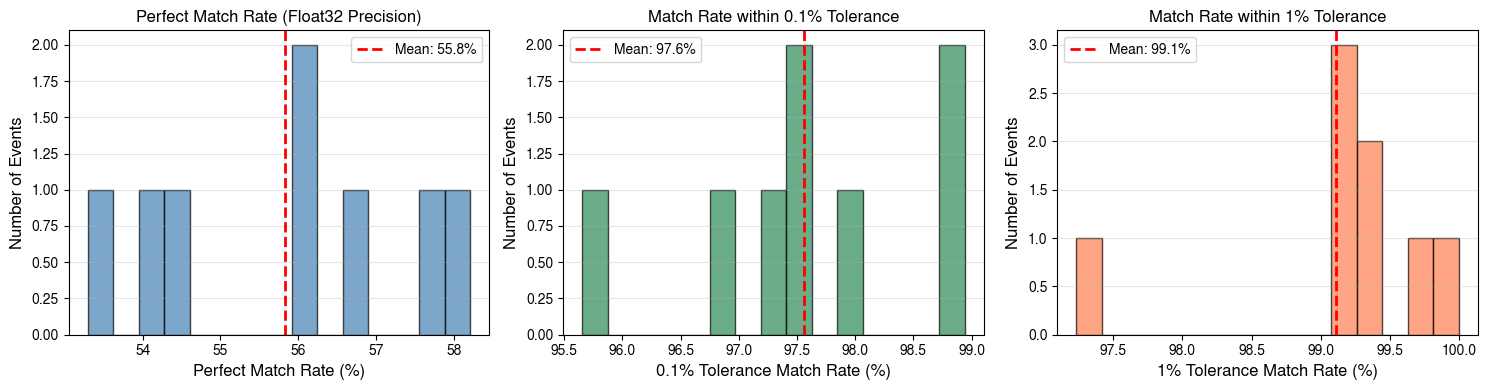

In [ ]:
# Calculate match rates at different tolerances
successful_events = validation_df[validation_df['status'] == 'SUCCESS'].copy()
successful_events['perfect_match_rate'] = successful_events['num_matched_perfect'] / successful_events['num_parquet_hs_gen']
successful_events['match_0p1pct_rate'] = successful_events['num_matched_0p1pct'] / successful_events['num_parquet_hs_gen']
successful_events['match_1pct_rate'] = successful_events['num_matched_1pct'] / successful_events['num_parquet_hs_gen']

print("Match Rates at Different Tolerances:")
print(successful_events[['local_event', 'perfect_match_rate', 'match_0p1pct_rate', 'match_1pct_rate']])
print(f"\nAverage rates across all events:")
print(f"  Perfect (float32): {successful_events['perfect_match_rate'].mean()*100:.2f}%")
print(f"  0.1% tolerance: {successful_events['match_0p1pct_rate'].mean()*100:.2f}%")
print(f"  1% tolerance: {successful_events['match_1pct_rate'].mean()*100:.2f}%")

# Create histogram of match rates
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(successful_events['perfect_match_rate']*100, bins=15, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Perfect Match Rate (%)', fontsize=12)
axes[0].set_ylabel('Number of Events', fontsize=12)
axes[0].set_title('Perfect Match Rate (Float32 Precision)', fontsize=12)
axes[0].axvline(successful_events['perfect_match_rate'].mean()*100, color='red', linestyle='--', linewidth=2, label=f"Mean: {successful_events['perfect_match_rate'].mean()*100:.1f}%")
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].hist(successful_events['match_0p1pct_rate']*100, bins=15, color='seagreen', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('0.1% Tolerance Match Rate (%)', fontsize=12)
axes[1].set_ylabel('Number of Events', fontsize=12)
axes[1].set_title('Match Rate within 0.1% Tolerance', fontsize=12)
axes[1].axvline(successful_events['match_0p1pct_rate'].mean()*100, color='red', linestyle='--', linewidth=2, label=f"Mean: {successful_events['match_0p1pct_rate'].mean()*100:.1f}%")
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

axes[2].hist(successful_events['match_1pct_rate']*100, bins=15, color='coral', edgecolor='black', alpha=0.7)
axes[2].set_xlabel('1% Tolerance Match Rate (%)', fontsize=12)
axes[2].set_ylabel('Number of Events', fontsize=12)
axes[2].set_title('Match Rate within 1% Tolerance', fontsize=12)
axes[2].axvline(successful_events['match_1pct_rate'].mean()*100, color='red', linestyle='--', linewidth=2, label=f"Mean: {successful_events['match_1pct_rate'].mean()*100:.1f}%")
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
